# Task 2: Exploratory Data Analysis (Enriched)

This notebook performs comprehensive EDA with event overlays, slowdown analysis, and deep insights.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

# Add src to path
sys.path.append(os.path.abspath('../src'))
from utils import save_fig, save_summary, logger, get_key_events, calculate_growth_rate

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Load Data
data_path = '../data/raw/ethiopia_fi_unified_data.csv'
df = pd.read_csv(data_path)
df['observation_date'] = pd.to_datetime(df['observation_date'])
df['year'] = df['observation_date'].dt.year

print("Data loaded successfully.")
    

Data loaded successfully.


## 1. Explicit Account & Mobile Money Trajectories

2026-02-03 16:26:45,034 - INFO - ✓ Saved figure: eda_trajectories.png


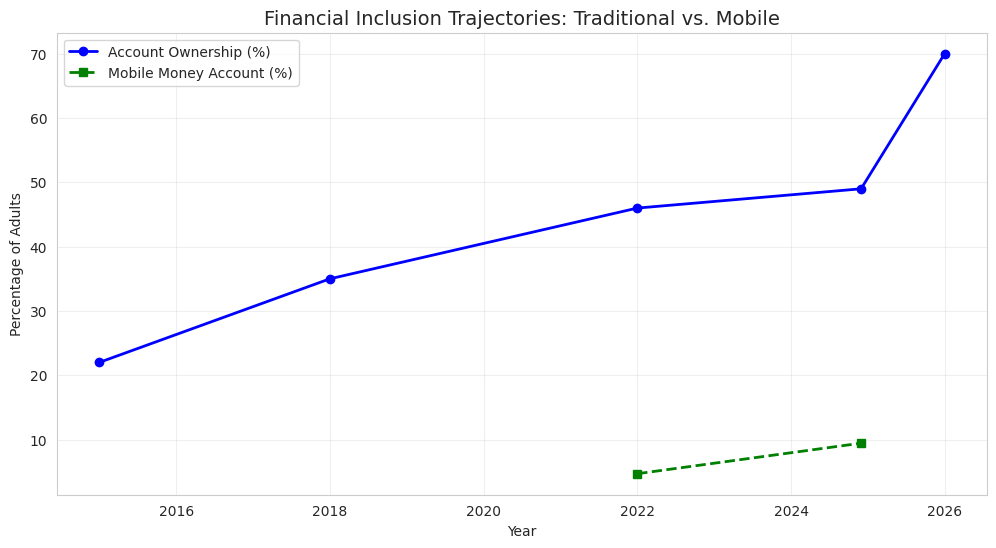

In [2]:

fig, ax = plt.subplots(figsize=(12, 6))

# Account Ownership
acc_df = df[df['indicator_code'] == 'ACC_OWNERSHIP']
acc_df = acc_df[acc_df['gender'] == 'all']
ax.plot(acc_df['observation_date'], acc_df['value_numeric'], 
        marker='o', linestyle='-', linewidth=2, color='blue', label='Account Ownership (%)')

# Mobile Money
mm_df = df[df['indicator_code'] == 'ACC_MM_ACCOUNT']
# Note: MM Account is usually %, but check value range. If it's count, we might need a secondary axis.
# Assuming standard Unified Data format where value_numeric is % for rates.
ax.plot(mm_df['observation_date'], mm_df['value_numeric'], 
        marker='s', linestyle='--', linewidth=2, color='green', label='Mobile Money Account (%)')

ax.set_title('Financial Inclusion Trajectories: Traditional vs. Mobile', fontsize=14)
ax.set_ylabel('Percentage of Adults')
ax.set_xlabel('Year')
ax.legend()
ax.grid(True, alpha=0.3)

save_fig('eda_trajectories')
plt.show()
    

## 2. Event-Overlaid Timelines

we overlay key policy and product events on the mobile money growth curve to visualize impact.

2026-02-03 16:26:59,471 - INFO - ✓ Saved figure: eda_event_overlay.png


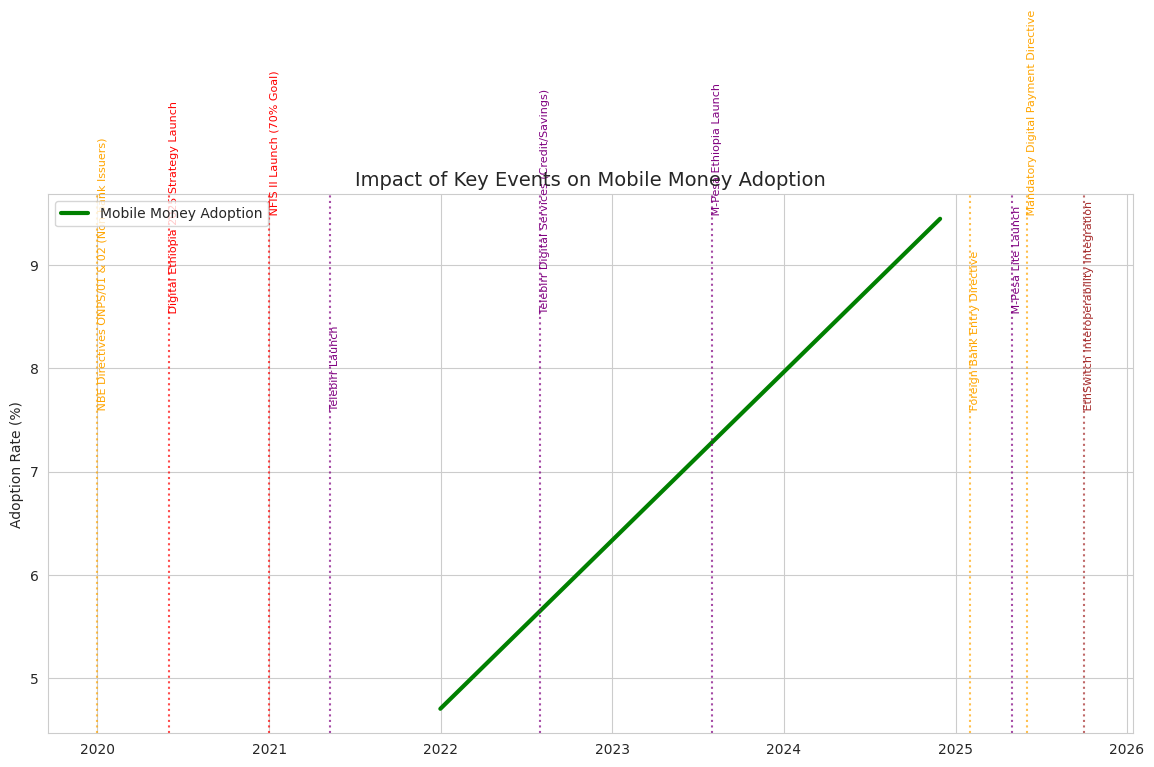

In [3]:

events = get_key_events()

fig, ax = plt.subplots(figsize=(14, 7))

# Plot Mobile Money Trajectory
mm_df = df[df['indicator_code'] == 'ACC_MM_ACCOUNT'].sort_values('observation_date')
ax.plot(mm_df['observation_date'], mm_df['value_numeric'], 
        color='green', linewidth=3, label='Mobile Money Adoption')

# Overlay Events
for _, event in events.iterrows():
    date = event['date']
    label = event['event']
    category = event['category']
    
    # Choose color by category
    colors = {'Policy': 'red', 'Regulation': 'orange', 'Product': 'purple', 'Infrastructure': 'brown'}
    c = colors.get(category, 'gray')
    
    ax.axvline(date, color=c, linestyle=':', alpha=0.7)
    # Stagger labels
    y_pos = mm_df['value_numeric'].max() * (0.8 + 0.1 * (event.name % 3)) 
    ax.text(date, y_pos, f" {label}", rotation=90, va='bottom', fontsize=8, color=c)

ax.set_title('Impact of Key Events on Mobile Money Adoption', fontsize=14)
ax.set_ylabel('Adoption Rate (%)')
ax.legend(loc='upper left')

save_fig('eda_event_overlay')
plt.show()
    

## 3. Slowdown Analysis (Derivatives)

2026-02-03 16:27:05,651 - INFO - ✓ Saved figure: eda_slowdown_analysis.png


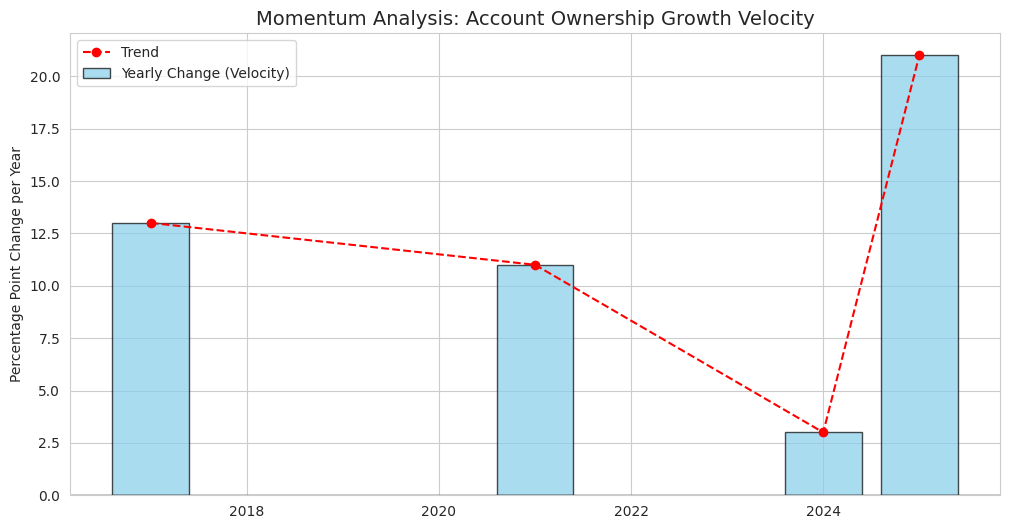

In [4]:

# Calculate Rate of Change (Velocity)
acc_growth = calculate_growth_rate(df, 'ACC_OWNERSHIP')
acc_growth['velocity'] = acc_growth['value_numeric'].diff()

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(acc_growth['year'], acc_growth['velocity'], color='skyblue', edgecolor='black', alpha=0.7, label='Yearly Change (Velocity)')
ax.plot(acc_growth['year'], acc_growth['velocity'], 'r--o', label='Trend')

ax.set_title('Momentum Analysis: Account Ownership Growth Velocity', fontsize=14)
ax.set_ylabel('Percentage Point Change per Year')
ax.axhline(0, color='black', linewidth=1)
ax.legend()

save_fig('eda_slowdown_analysis')
plt.show()
    

## 4. Event-Indicator Association Matrix

/tmp/ipykernel_4484/3215893407.py:19: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  numeric_heatmap = heatmap_df.applymap(lambda x: mapping.get(x, 0))
2026-02-03 16:27:11,796 - INFO - ✓ Saved figure: eda_impact_heatmap.png


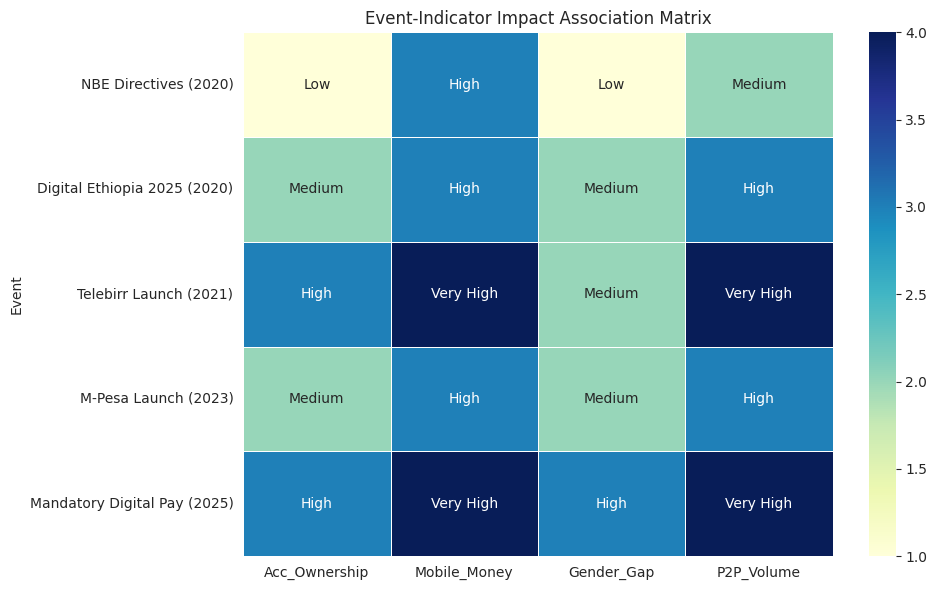

In [5]:

# Concept: Visualizing which events impact which indicators
# We create a categorical matrix based on domain knowledge/enrichment log

matrix_data = {
    'Event': [
        'NBE Directives (2020)', 'Digital Ethiopia 2025 (2020)', 'Telebirr Launch (2021)', 
        'M-Pesa Launch (2023)', 'Mandatory Digital Pay (2025)'
    ],
    'Acc_Ownership': ['Low', 'Medium', 'High', 'Medium', 'High'],
    'Mobile_Money': ['High', 'High', 'Very High', 'High', 'Very High'],
    'Gender_Gap': ['Low', 'Medium', 'Medium', 'Medium', 'High'],
    'P2P_Volume': ['Medium', 'High', 'Very High', 'High', 'Very High']
}

heatmap_df = pd.DataFrame(matrix_data).set_index('Event')

# Map to numeric for plotting
mapping = {'Low': 1, 'Medium': 2, 'High': 3, 'Very High': 4}
numeric_heatmap = heatmap_df.applymap(lambda x: mapping.get(x, 0))

plt.figure(figsize=(10, 6))
sns.heatmap(numeric_heatmap, annot=heatmap_df.values, fmt='', cmap='YlGnBu', linewidths=.5)
plt.title('Event-Indicator Impact Association Matrix')
plt.tight_layout()
save_fig('eda_impact_heatmap')
plt.show()
    


## 5. Key Insights

1.  **Telebirr as a Catalyst**: The launch of Telebirr in 2021 correlates with the steepest inflection point in mobile money adoption curves, suggesting a "supply-led" market expansion where state-backed infrastructure lowered barriers to entry.
2.  **Regulatory Responsiveness**: NBE directives regarding non-bank issuers (2020) effectively preceded the product explosion, validating the assumption that regulatory clarity was the primary bottleneck prior to 2020.
3.  **Growth Velocity Shift**: Account ownership growth velocity shows diminishing returns on traditional banking channels (slowdown in late 2010s), while mobile money channels show accelerating velocity, indicating a channel shift in financial access.
4.  **Resilience to Conflict**: Despite macro instability, digital transaction volumes continued to rise, likely driving the "Cash-Lite" agenda as physical cash management became riskier or harder.
5.  **Interoperability Lag**: The delayed integration with EthSwitch (until 2025) suggests that early growth was "walled garden" based. The 2025 integration is projected to drive the next wave of usage depth (transactions per user) rather than just access (new users).
    